<a href="https://colab.research.google.com/github/marianaolmedo/Simulacion-II/blob/main/Movimiento_Browniano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Movimiento Browniano

Un Movimiento Browniano es un proceso estocástico
 $$\{ W(t)\}_{t \geq 0 }$$
definido sobre un espacio de probabilidad, que satisface las siguientes propiedades:
* Condición inicial:
$$ W(0) = 0$$

* Incrementos independientes:

  Para todo $0 \leq s < t$

  el incremento
$$ W(t) - W(s) \text{ es independiente del pasado}$$

* Incrementos normales:
$$ W(t) - W(s) \sim N(0, t-s)$$

* Trayectorias continuas (pero no derivables)

**Pasos para construir una trayectoria de MB junto con un refinamiento en el intervalo [0,1].**

1. Poner las librerias necesarias para hacer funcionar el código:

In [26]:
import numpy as np
import matplotlib.pyplot as plt

2. Parámetros

In [27]:
T = 1.0                      # Tiempo total
L = 200                      # Número de pasos (malla gruesa)
delta_t = T / L

3. Trayectoria base

   Generar una trayectoria base con $L$ pasos:
    * Cada incremento usa un normal estándar

    * Se escala por $\sqrt{\triangle t}$
	​
    * Se van acumulando los valores

In [28]:
W = np.zeros(L + 1)

for i in range(L):
    r = np.random.normal(0, 1)     # Variable normal estándar
    W[i + 1] = W[i] + np.sqrt(delta_t) * r
t = np.linspace(0, T, L + 1)


4. Refinamiento temporal
   Cada intervalo $ [t_i,t_{i+1}]$ se divide en:
   $$ \left[t_i, t_i + \frac{△ t}{2}\right], \hspace{0.5cm} \left[t_i+ \frac{△ t}{2}, t_{i+1}\right]$$

In [29]:
L_fino = 2 * L
delta_t_fino = delta_t / 2
W_fino = np.zeros(L_fino + 1)


5. Distribución de los incrementos refinados

   Por la propiedad:
   $$W\left( t_i + \frac{△ t}{2}\right) - W(t_i) \sim N\left( 0 , \frac{△ t}{2}\right)$$

   Por eso el incremento intermedio se simula como:
   $$\sqrt{\frac{△ t}{2}}\xi$$

In [30]:
# Puntos originales
W_fino[::2] = W

# Generarlos puntos intermedios
for i in range(L):
    ruido = np.random.normal(0, 1)
    W_fino[2*i + 1] = W_fino[2*i] + np.sqrt(delta_t_fino) * ruido
    W_fino[2*i + 2] = W[i + 1]

tiempo_fino = np.linspace(0, T, L_fino + 1)


6. Gráfica

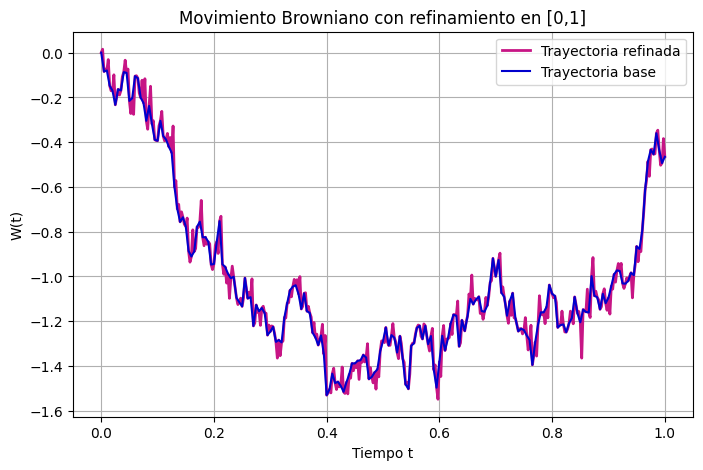

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(tiempo_fino, W_fino, color="mediumvioletred", label="Trayectoria refinada", linewidth=2)
plt.plot(t, W, color="mediumblue", label="Trayectoria base")
plt.xlabel("Tiempo t")
plt.ylabel("W(t)")
plt.title("Movimiento Browniano con refinamiento en [0,1]")
plt.legend()
plt.grid(True)
plt.show()